In [13]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from particle import Particle
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

In [14]:
file = uproot.open("../full_Hsphere/MuravesSim_Data_20260310_113155.root")
#print(file.keys())

gen_tree = file["PrimaryGenData_NT"]
hit_tree = file["HitData_NT"]

In [15]:
hit_df = hit_tree.arrays(
    ["Event", "ScintHitBar", "ScintHitModule", "ScintHitStation", "ScintHitE", "ScintHitPDG", "ScintHitTrackID", "ScintHitParentID"],
    library="pd"   # load as pandas dataframe
)
hit_df.columns = ["event", "bar", "module", "station", "energy", "pdg", "track_id", "parent_id"]

gen_df = gen_tree.arrays(["Event", "GenPartPhi", "GenPartTheta", "GenPartPDG", "GenPartE"], library="pd")
gen_df.columns =  ["event", "phi", "theta", "pdg", "energy"]

In [22]:
# ── 1. IDENTIFY NEAR-MISS EVENTS ─────────────────────────────────────────────
# Near-miss: station 2 OR station 10 not triggered (but event has hits)

all_stations = sorted(hit_df["station"].unique())  # [0, 1, 2, 3, 8, 9, 10, 11]
n_full = len(all_stations)  # 8

stations_per_event = (
    hit_df.groupby("event")["station"]
    .apply(set)
    .reset_index()
    .rename(columns={"station": "stations_hit"})
)
stations_per_event["n_stations"] = stations_per_event["stations_hit"].apply(len)

# Near-miss: missing station 2 or 10 (but not both — those are deeper misses)
stations_per_event["has_st2"]  = stations_per_event["stations_hit"].apply(lambda s: 2  in s)
stations_per_event["has_st10"] = stations_per_event["stations_hit"].apply(lambda s: 10 in s)

near_miss_mask    = ~stations_per_event["has_st2"] | ~stations_per_event["has_st10"]
full_trigger_mask =  stations_per_event["has_st2"] & stations_per_event["has_st10"]

near_miss_ids    = stations_per_event.loc[near_miss_mask,    "event"]
full_trigger_ids = stations_per_event.loc[full_trigger_mask, "event"]

near_miss_hits = hit_df[hit_df["event"].isin(near_miss_ids)].copy()
full_hits      = hit_df[hit_df["event"].isin(full_trigger_ids)].copy()

# Tag which key station is missing per event
stations_per_event["missing_key_station"] = None
stations_per_event.loc[~stations_per_event["has_st2"]  &  stations_per_event["has_st10"], "missing_key_station"] = 2
stations_per_event.loc[ stations_per_event["has_st2"]  & ~stations_per_event["has_st10"], "missing_key_station"] = 10
stations_per_event.loc[~stations_per_event["has_st2"]  & ~stations_per_event["has_st10"], "missing_key_station"] = "both"

print(f"Near-miss events (st2 or st10 missing): {near_miss_ids.nunique():>6,}")
print(f"Full-trigger events (st2 and st10 hit): {full_trigger_ids.nunique():>6,}")
print(f"Near-miss fraction                     : {near_miss_ids.nunique() / stations_per_event.shape[0]:.2%}")
print("\nMissing key station breakdown:")
print(stations_per_event.loc[near_miss_mask, "missing_key_station"].value_counts())

Near-miss events (st2 or st10 missing): 18,968
Full-trigger events (st2 and st10 hit):  5,135
Near-miss fraction                     : 78.70%

Missing key station breakdown:
missing_key_station
both    16081
2        1465
10       1422
Name: count, dtype: int64


In [23]:
# ── 2. MERGE WITH GENERATOR INFO ─────────────────────────────────────────────

nm_gen = stations_per_event[near_miss_mask].merge(gen_df, on="event", how="left")
ft_gen = stations_per_event[full_trigger_mask].merge(gen_df, on="event", how="left")

# ── 3. ENERGY DEPOSITION PER STATION ─────────────────────────────────────────

energy_station_nm = (
    near_miss_hits.groupby(["event", "station"])["energy"]
    .sum().reset_index()
)
energy_station_ft = (
    full_hits.groupby(["event", "station"])["energy"]
    .sum().reset_index()
)

avg_energy_nm = energy_station_nm.groupby("station")["energy"].mean()
avg_energy_ft = energy_station_ft.groupby("station")["energy"].mean()

# ── 4. GAP ANALYSIS ───────────────────────────────────────────────────────────

gap_nm = (
    near_miss_hits.groupby("event")["bar"]
    .apply(max_gap).reset_index().rename(columns={"bar": "max_gap"})
)
gap_ft = (
    full_hits.groupby("event")["bar"]
    .apply(max_gap).reset_index().rename(columns={"bar": "max_gap"})
)
adj_nm = (
    near_miss_hits.groupby("event")["bar"]
    .apply(check_adjacency).reset_index().rename(columns={"bar": "is_adjacent"})
)
adj_ft = (
    full_hits.groupby("event")["bar"]
    .apply(check_adjacency).reset_index().rename(columns={"bar": "is_adjacent"})
)

print(f"\nAdjacency (near-miss) : {adj_nm['is_adjacent'].mean():.2%}")
print(f"Adjacency (full-trig) : {adj_ft['is_adjacent'].mean():.2%}")

# ── 5. TOTAL ENERGY PER EVENT ─────────────────────────────────────────────────

total_energy_nm = near_miss_hits.groupby("event")["energy"].sum().values
total_energy_ft = full_hits.groupby("event")["energy"].sum().values


Adjacency (near-miss) : 19.82%
Adjacency (full-trig) : 2.65%


In [19]:
def max_gap(bars):
    """Returns the maximum gap between any two consecutive hit bars."""
    sorted_bars = sorted(bars)
    if len(sorted_bars) < 2:
        return 0
    return max(b2 - b1 for b1, b2 in zip(sorted_bars, sorted_bars[1:]))

def check_adjacency(bars):
    """Returns True if all hit bars are consecutive (max gap == 1)."""
    sorted_bars = sorted(bars)
    if len(sorted_bars) < 2:
        return True
    return max(b2 - b1 for b1, b2 in zip(sorted_bars, sorted_bars[1:])) == 1

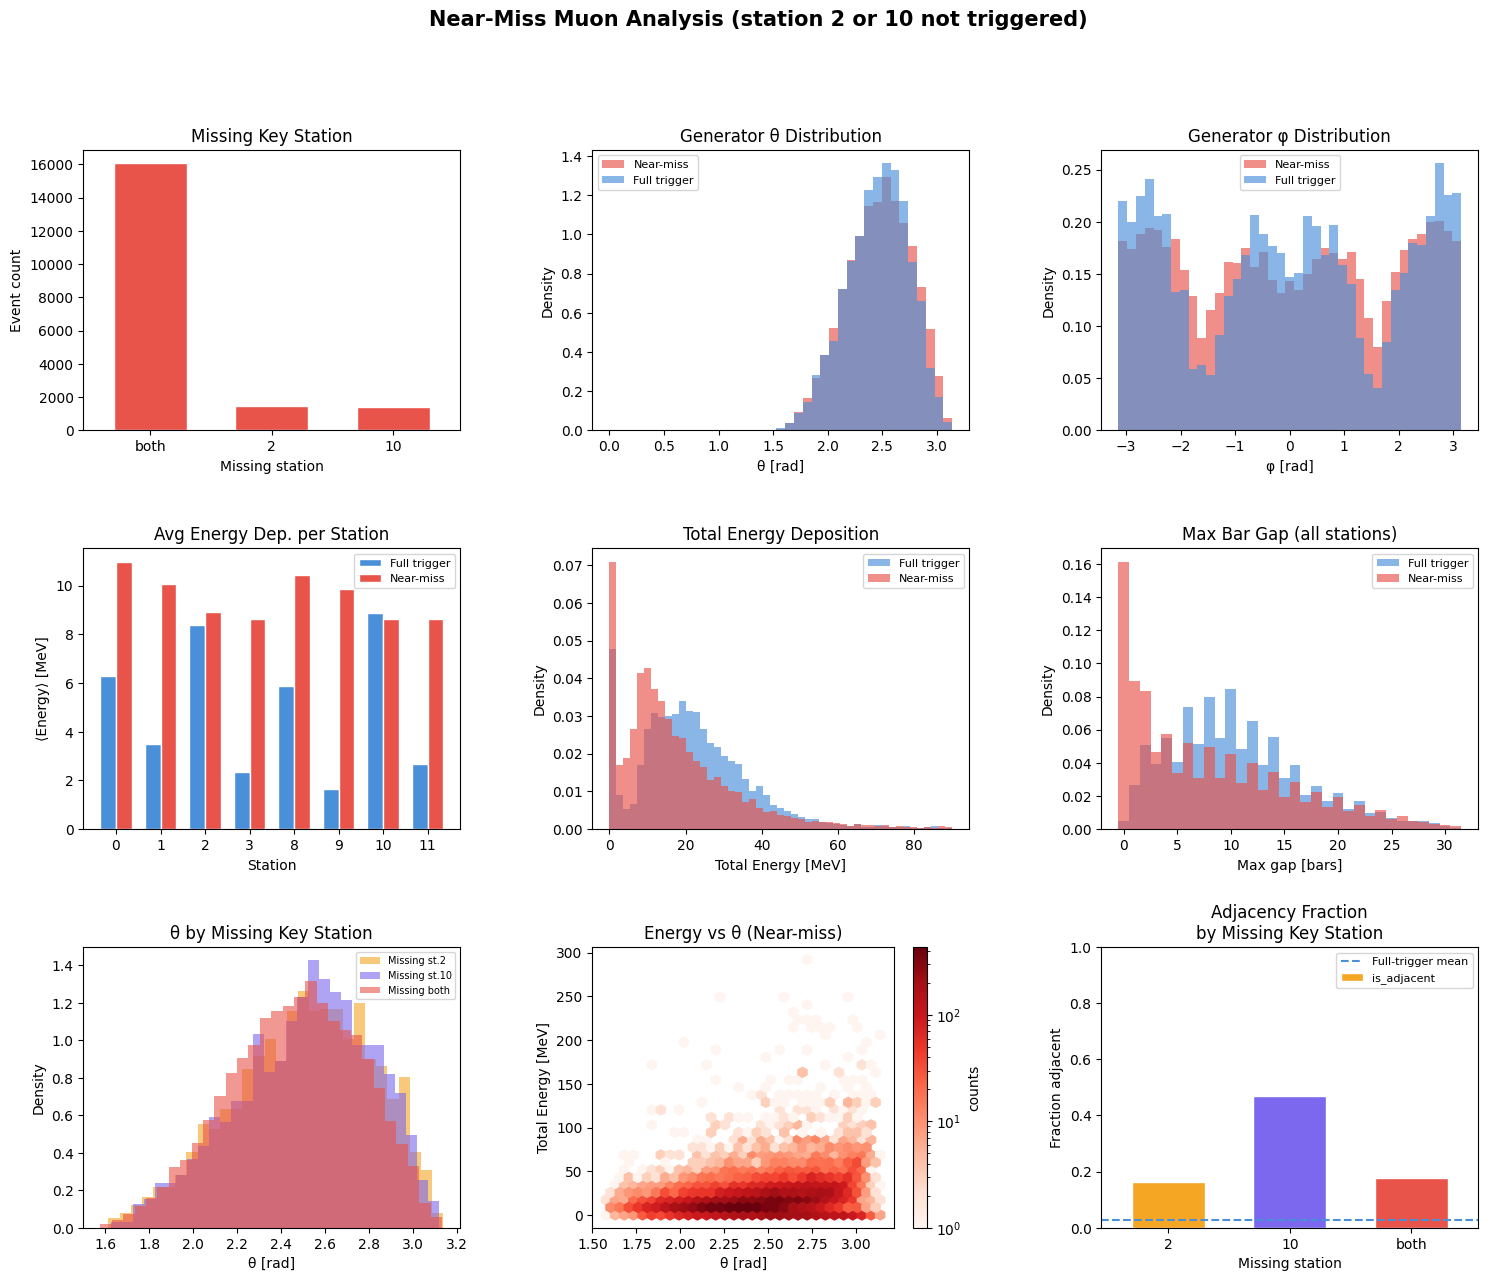


── Summary Statistics ──────────────────────────────────────────────────
Metric                                    Near-miss Full-trigger
-----------------------------------------------------------------
N events                                     18,968        5,135
Median total energy [MeV]                     13.95        20.64
Mean θ [rad]                                  2.468        2.457
Fraction fully adjacent                      19.82%        2.65%
Mean max bar gap                               7.92        10.54


In [24]:
# ── 6. PLOTTING ───────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Near-Miss Muon Analysis (station 2 or 10 not triggered)",
             fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

NM_COLOR = "#E8534A"
FT_COLOR = "#4A90D9"
ST2_COLOR  = "#F5A623"   # orange for missing st2
ST10_COLOR = "#7B68EE"   # purple for missing st10
alpha = 0.65

# ── 6a. Missing key station breakdown ────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
stations_per_event.loc[near_miss_mask, "missing_key_station"].value_counts().plot(
    kind="bar", ax=ax0, color=NM_COLOR, edgecolor="white", width=0.6)
ax0.set_title("Missing Key Station")
ax0.set_xlabel("Missing station")
ax0.set_ylabel("Event count")
ax0.tick_params(axis="x", rotation=0)

# ── 6b. Theta distribution ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
theta_bins = np.linspace(0, np.pi, 40)
ax1.hist(nm_gen["theta"].dropna(), bins=theta_bins,
         color=NM_COLOR, alpha=alpha, density=True, label="Near-miss")
ax1.hist(ft_gen["theta"].dropna(), bins=theta_bins,
         color=FT_COLOR, alpha=alpha, density=True, label="Full trigger")
ax1.set_title("Generator θ Distribution")
ax1.set_xlabel("θ [rad]")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)

# ── 6c. Phi distribution ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
phi_bins = np.linspace(-np.pi, np.pi, 40)
ax2.hist(nm_gen["phi"].dropna(), bins=phi_bins,
         color=NM_COLOR, alpha=alpha, density=True, label="Near-miss")
ax2.hist(ft_gen["phi"].dropna(), bins=phi_bins,
         color=FT_COLOR, alpha=alpha, density=True, label="Full trigger")
ax2.set_title("Generator φ Distribution")
ax2.set_xlabel("φ [rad]")
ax2.set_ylabel("Density")
ax2.legend(fontsize=8)

# ── 6d. Avg energy per station ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
x = np.arange(len(all_stations))
w = 0.35
ax3.bar(x - w/2, avg_energy_ft.reindex(all_stations, fill_value=0),
        width=w, color=FT_COLOR, label="Full trigger", edgecolor="white")
ax3.bar(x + w/2, avg_energy_nm.reindex(all_stations, fill_value=0),
        width=w, color=NM_COLOR, label="Near-miss", edgecolor="white")
ax3.set_title("Avg Energy Dep. per Station")
ax3.set_xlabel("Station")
ax3.set_ylabel("⟨Energy⟩ [MeV]")
ax3.set_xticks(x); ax3.set_xticklabels(all_stations)
ax3.legend(fontsize=8)

# ── 6e. Total energy distribution ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
energy_max = np.percentile(np.concatenate([total_energy_nm, total_energy_ft]), 99)
energy_bins = np.linspace(0, energy_max, 50)
ax4.hist(total_energy_ft, bins=energy_bins,
         color=FT_COLOR, alpha=alpha, density=True, label="Full trigger")
ax4.hist(total_energy_nm, bins=energy_bins,
         color=NM_COLOR, alpha=alpha, density=True, label="Near-miss")
ax4.set_title("Total Energy Deposition")
ax4.set_xlabel("Total Energy [MeV]")
ax4.set_ylabel("Density")
ax4.legend(fontsize=8)

# ── 6f. Max gap distribution ──────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
gap_max = int(max(gap_nm["max_gap"].max(), gap_ft["max_gap"].max())) + 1
gap_bins = np.arange(0, gap_max + 1) - 0.5
ax5.hist(gap_ft["max_gap"], bins=gap_bins,
         color=FT_COLOR, alpha=alpha, density=True, label="Full trigger")
ax5.hist(gap_nm["max_gap"], bins=gap_bins,
         color=NM_COLOR, alpha=alpha, density=True, label="Near-miss")
ax5.set_title("Max Bar Gap (all stations)")
ax5.set_xlabel("Max gap [bars]")
ax5.set_ylabel("Density")
ax5.legend(fontsize=8)

# ── 6g. Theta split by which key station is missing ───────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
nm_with_gen = stations_per_event[near_miss_mask].merge(gen_df, on="event", how="left")
for mst, color, label in [(2, ST2_COLOR, "Missing st.2"),
                           (10, ST10_COLOR, "Missing st.10"),
                           ("both", NM_COLOR, "Missing both")]:
    subset = nm_with_gen[nm_with_gen["missing_key_station"] == mst]["theta"].dropna()
    if len(subset):
        ax6.hist(subset, bins=30, alpha=0.6, density=True, color=color, label=label)
ax6.set_title("θ by Missing Key Station")
ax6.set_xlabel("θ [rad]")
ax6.set_ylabel("Density")
ax6.legend(fontsize=7)

# ── 6h. Energy vs theta (near-miss) ───────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
nm_energy_theta = (
    near_miss_hits.groupby("event")["energy"].sum()
    .reset_index()
    .merge(gen_df[["event", "theta"]], on="event", how="left")
)
sc = ax7.hexbin(nm_energy_theta["theta"], nm_energy_theta["energy"],
                gridsize=30, cmap="Reds", mincnt=1, norm=LogNorm())
plt.colorbar(sc, ax=ax7, label="counts")
ax7.set_title("Energy vs θ (Near-miss)")
ax7.set_xlabel("θ [rad]")
ax7.set_ylabel("Total Energy [MeV]")

# ── 6i. Adjacency fraction by missing key station ─────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
adj_by_missing = (
    adj_nm.merge(stations_per_event[["event", "missing_key_station"]], on="event")
    .groupby("missing_key_station")["is_adjacent"]
    .mean()
)
adj_by_missing.plot(kind="bar", ax=ax8, color=[ST2_COLOR, ST10_COLOR, NM_COLOR],
                    edgecolor="white", width=0.6)
ax8.set_title("Adjacency Fraction\nby Missing Key Station")
ax8.set_xlabel("Missing station")
ax8.set_ylabel("Fraction adjacent")
ax8.set_ylim(0, 1)
ax8.tick_params(axis="x", rotation=0)
ax8.axhline(adj_ft["is_adjacent"].mean(), color=FT_COLOR,
            linestyle="--", linewidth=1.5, label="Full-trigger mean")
ax8.legend(fontsize=8)

plt.savefig("near_miss_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. SUMMARY TABLE ─────────────────────────────────────────────────────────

print("\n── Summary Statistics ──────────────────────────────────────────────────")
print(f"{'Metric':<38} {'Near-miss':>12} {'Full-trigger':>12}")
print("-" * 65)
print(f"{'N events':<38} {near_miss_ids.nunique():>12,} {full_trigger_ids.nunique():>12,}")
print(f"{'Median total energy [MeV]':<38} {np.median(total_energy_nm):>12.2f} {np.median(total_energy_ft):>12.2f}")
print(f"{'Mean θ [rad]':<38} {nm_gen['theta'].mean():>12.3f} {ft_gen['theta'].mean():>12.3f}")
print(f"{'Fraction fully adjacent':<38} {adj_nm['is_adjacent'].mean():>12.2%} {adj_ft['is_adjacent'].mean():>12.2%}")
print(f"{'Mean max bar gap':<38} {gap_nm['max_gap'].mean():>12.2f} {gap_ft['max_gap'].mean():>12.2f}")